# Causal inference

## Imports

In [4]:
%load_ext autoreload
%autoreload 2

import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import helpers.hmatplotlib as hmatplo
import helpers.hpandas_display as hpandisp

import helpers.htutorial as ut
import L08_04_01_causal_inference_utils as mtl0cireout

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

dir_name = "L08_data"
!ls $dir_name

out_dir_name = "figures/"
markdown_path_prefix = "msml610/lectures_source"

INFO:msml610_utils:Setting notebook style
INFO:msml610_utils:Notebook signature
INFO:msml610_utils:numpy version=1.26.4
INFO:msml610_utils:pymc version=5.18.2
INFO:msml610_utils:matplotlib version=3.10.3
INFO:msml610_utils:arviz version=0.21.0
INFO:msml610_utils:preliz version=0.19.0


Python 3.12.3
Linux df0445a574d1 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


# Part 1: Sales Example

## Cell 1.1: Loading the sales data

**Goal**:
- Analyze real-world sales data to illustrate the challenge of causal
  inference: observational data can be misleading due to confounding

**Implementation**: `mtl0cireout.load_xmas_sales_data(dir_name)`

In [6]:
data = mtl0cireout.load_xmas_sales_data(dir_name)
print("data.shape=", data.shape)
display(data.head(6))

Module 'dataframe_image' is already installed.


In [ ]:
xmas_sales_df_png = f"{out_dir_name}/L08.4.xmas_sales_df.png"
hpandisp.convert_df_to_png(
    data.head(6),
    xmas_sales_df_png,
    index=True,
    print_markdown=True,
    markdown_path_prefix=markdown_path_prefix,
)

## Cell 1.2: Visualizing sales by treatment status

**Goal**:
- Compare sales outcomes between stores with and without price cuts

**Implementation**: `mtl0cireout.plot_xmas_sales_boxplot(data)`
- Box plots of weekly sales for treated (cut prices) and control (no
  price cut) groups: visual evidence suggests price cuts increase
  sales, but this may reflect confounding rather than a true causal
  effect

In [7]:
fig = mtl0cireout.plot_xmas_sales_boxplot(data)
xmas_boxplot_png = f"{out_dir_name}/L08.4.xmas_boxplot.png"
hmatplo.save_fig(
    fig, xmas_boxplot_png, print_markdown=True, path_prefix=markdown_path_prefix
)

## Cell 1.3: Conceptual example: potential outcomes

**Goal**:
- Illustrate the fundamental problem of causal inference using
  potential outcomes: each unit `i` has 2 potential outcomes, `y0`
  (under control) and `y1` (under treatment), but only one is ever
  observed

In [8]:
# i = unit identifier
# y0, y1 = potential outcomes under control and treatment (idealized situation)
# t = treatment indicator
# x = group
# df1 = pd.DataFrame(
#     dict(
#         i=[1, 2, 3, 4, 5, 6],
#         y0=[200, 120, 300, 450, 600, 600],
#         y1=[220, 140, 400, 500, 600, 800],
#         t=[0, 0, 0, 1, 1, 1],
#         x=[0, 0, 1, 0, 0, 1],
#     )
# )
# df1

(2000, 5)


,store,weeks_to_xmas,avg_week_sales,is_on_sale,weekly_amount_sold
0,1,3,12.98,1.0,219.60
1,1,2,12.98,1.0,184.70
2,1,1,12.98,1.0,145.75
3,1,0,12.98,0.0,102.45
4,2,3,19.92,0.0,103.22
5,2,2,19.92,0.0,53.73


In [9]:
# # Select the outcome based on the treatment.
# df1["y"] = (df1["t"] * df1["y1"] + (1 - df1["t"]) * df1["y0"]).astype(int)
#
# # Treatment effect.
# df1["te"] = df1["y1"] - df1["y0"]
#
# df1

PNG image saved to: 'figures/L08.4.xmas_sales_df.png'
![](msml610/lectures_source/figures/L08.4.xmas_sales_df.png)


In [ ]:
# df2 = pd.DataFrame(
#     dict(
#         i=[1, 2, 3, 4, 5, 6],
#         y0=[200, 120, 300, np.nan, np.nan, np.nan],
#         y1=[np.nan, np.nan, np.nan, 500, 600, 800],
#         t=[0, 0, 0, 1, 1, 1],
#         x=[0, 0, 1, 0, 0, 1],
#     )
# )
# df2

In [ ]:
# # Select the outcome based on the treatment.
# df2["y"] = (df2["t"] * df2["y1"] + (1 - df2["t"]) * df2["y0"]).astype(int)
#
# # Treatment effect.
# df2["te"] = df2["y1"] - df2["y0"]
#
# df2

## Cell 1.4: Visualizing bias from pooling treated/control stores

**Goal**:
- Visualize scatter points and regression lines for treated and
  control stores

**Implementation**: `mtl0cireout.plot_sales_bias_analysis(data)`
- Treated stores (red) and control stores (blue), each with its own
  regression trend: within each group, the relationship between
  baseline sales and treatment appears similar, but the overall pooled
  relationship is different

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Saved figure to 'figures/L08.4.xmas_boxplot.png'
![](msml610/lectures_source/figures/L08.4.xmas_boxplot.png)


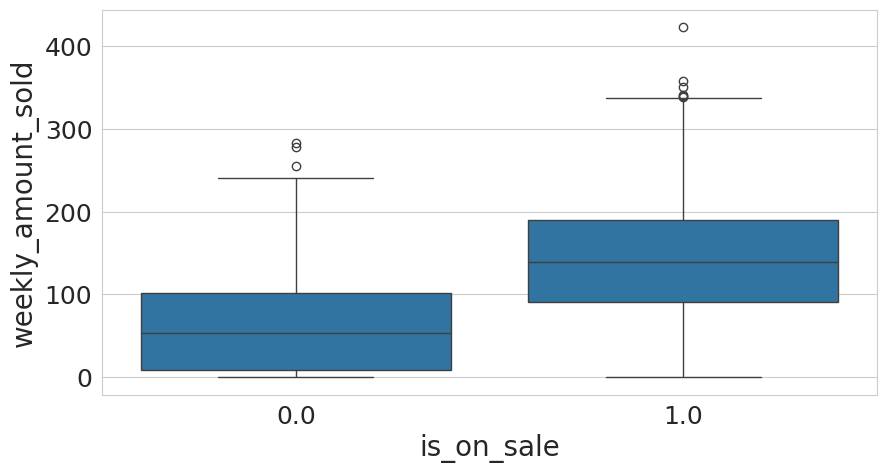

In [10]:
fig = mtl0cireout.plot_sales_bias_analysis(data)
bias_analysis0_png = f"{out_dir_name}/L08.4.Association_Causation_Bias0.png"
hmatplo.save_fig(
    fig,
    bias_analysis0_png,
    print_markdown=True,
    path_prefix=markdown_path_prefix,
)

## Cell 1.5: Comparing pooled vs stratified trends

**Goal**:
- Compare pooled vs stratified regression models on synthetic data

**Implementation**: `mtl0cireout.plot_single_vs_separate_trends()`
- Left panel: single trend line across all data. Right panel: separate
  trend lines for large and small businesses. Simpson's paradox
  emerges when aggregation obscures group-level trends, and
  stratification reveals the true relationships

In [11]:
fig = mtl0cireout.plot_single_vs_separate_trends()
bias_analysis1_png = f"{out_dir_name}/L08.4.Association_Causation_Bias1.png"
hmatplo.save_fig(
    fig,
    bias_analysis1_png,
    print_markdown=True,
    path_prefix=markdown_path_prefix,
)

## Cell 1.6: Simpson's paradox

**Goal**:
- Illustrate Simpson's paradox, where the aggregate and group-level
  trends contradict each other

**Implementation**: `mtl0cireout.plot_simpsons_paradox()`
- 2 groups (blue and red), each with a positive within-group trend,
  but a negative overall trend: ignoring a confounding variable (like
  business size) leads to contradictory causal conclusions

In [12]:
fig = mtl0cireout.plot_simpsons_paradox()
simpsons_paradox_png = f"{out_dir_name}/L08.4.Simpson_Paradox.png"
hmatplo.save_fig(
    fig,
    simpsons_paradox_png,
    print_markdown=True,
    path_prefix=markdown_path_prefix,
)

## Cell 1.7: University Simpson's paradox

**Goal**:
- Demonstrate Simpson's paradox in a university-admissions context
  with 2 different groups

**Implementation**: `mtl0cireout.plot_university_simpsons_paradox()`
- Left panel: groups A and B each with a positive admission trend.
  Right panel: the aggregated data shows a reversed, negative overall
  trend. Ignoring group differences (e.g., selectivity, baseline
  rates) leads to reversed causal conclusions in aggregate data

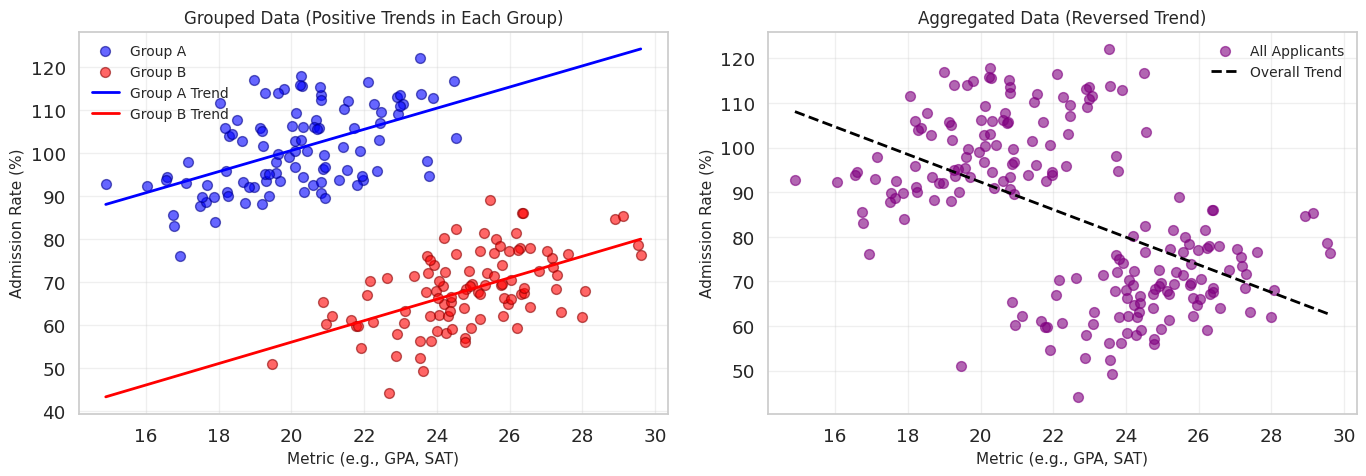

In [18]:
fig = mtl0cireout.plot_university_simpsons_paradox()

# Part 2: A/B Testing

## Cell 2.1: Loading the email A/B test data

**Goal**:
- Apply causal inference concepts to A/B testing with email marketing
  data, to measure treatment effects and quantify their uncertainty

In [28]:
data = pd.read_csv(f"{dir_name}/cross_sell_email.csv")
print("data.shape=", data.shape)
display(data.head(3))

(323, 4)


,gender,cross_sell_email,age,conversion
0,0,short,15,0
1,1,short,27,0
2,1,long,17,0


## Cell 2.2: Checking covariate balance across groups

**Goal**:
- Check that the treatment groups are balanced on observed covariates,
  a precondition for a clean treatment-effect comparison

In [22]:
display(data.groupby(["cross_sell_email"]).mean())

,gender,age,conversion
cross_sell_email,,,
long,0.550459,21.752294,0.055046
no_email,0.542553,20.489362,0.042553
short,0.633333,20.991667,0.125000


In [25]:
# Evaluate balance co-variate.
covariates = ["gender", "age"]
mu = data.groupby("cross_sell_email")[covariates].mean()
var = data.groupby("cross_sell_email")[covariates].var()
norm_diff = (mu - mu.loc["no_email"]) / np.sqrt((var + var.loc["no_email"]) / 2)
display(norm_diff)

,gender,age
cross_sell_email,,
long,0.015802,0.221423
no_email,0.000000,0.000000
short,0.184341,0.087370


## Cell 2.3: Regression to the mean in school scores

**Goal**:
- Illustrate regression to the mean using school-score data, showing
  how selection effects can mislead causal conclusions

**Implementation**: `mtl0cireout.plot_top_school_size_boxplot(df)`,
`mtl0cireout.plot_score_by_school_size_scatter(df)`
- Top-scoring schools skew smaller: a school's small size (and hence
  noisier average score) can push it into the "top 1%" by chance,
  which is why the top and bottom of the score distribution both have
  disproportionately small schools

In [29]:
df = pd.read_csv(f"{dir_name}/enem_scores.csv")
print("df.shape=", df.shape)
display(df.head(3))

(37941, 4)


,year,school_id,number_of_students,avg_score
0,2007,11000058,144,69.03
1,2006,11000058,184,57.82
2,2005,11000058,220,64.83


In [31]:
display(df.sort_values(by="avg_score", ascending=False).head(5))

,year,school_id,number_of_students,avg_score
16670,2007,33062633,68,82.97
16796,2007,33065403,172,82.04
16668,2005,33062633,59,81.89
16794,2005,33065403,177,81.66
10043,2007,29342880,43,80.32


Text(0.5, 1.0, 'Number of Students of 1% Top Schools (Right)')

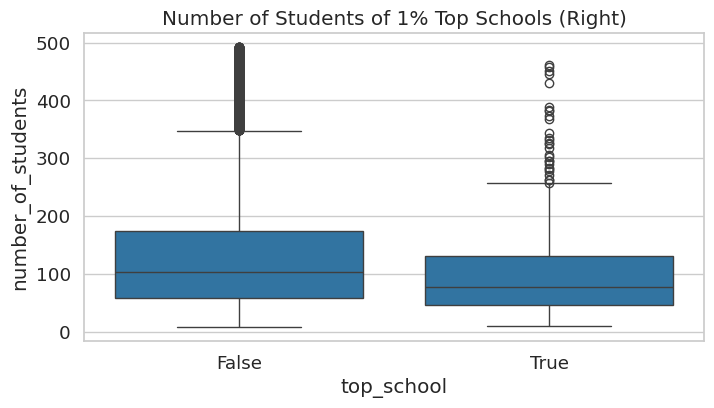

In [32]:
fig = mtl0cireout.plot_top_school_size_boxplot(df)
top_school_size_png = f"{out_dir_name}/L08.4.top_school_size.png"
hmatplo.save_fig(
    fig, top_school_size_png, print_markdown=True, path_prefix=markdown_path_prefix
)

Saved figure to 'figures/L08.4.School_score_by_number_students.png'
![](msml610/lectures_source/figures/L08.4.School_score_by_number_students.png)


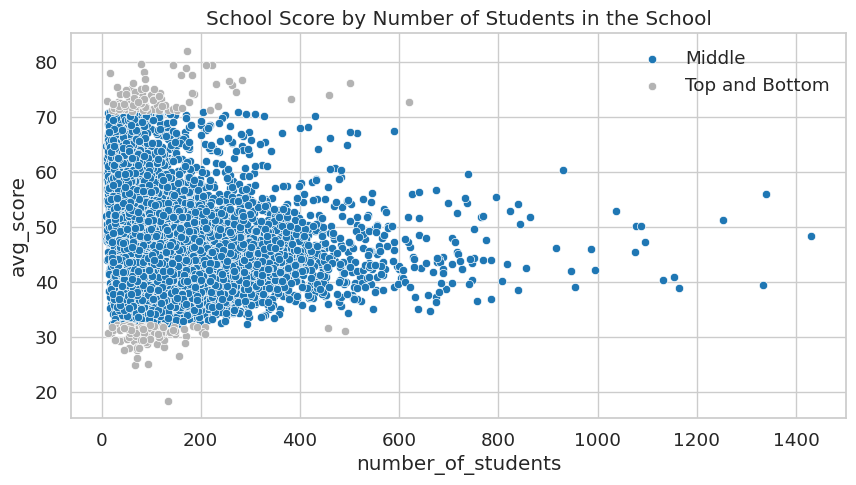

In [35]:
fig = mtl0cireout.plot_score_by_school_size_scatter(df)
score_by_school_size_png = f"{out_dir_name}/L08.4.School_score_by_number_students.png"
hmatplo.save_fig(
    fig,
    score_by_school_size_png,
    print_markdown=True,
    path_prefix=markdown_path_prefix,
)

## Cell 2.4: Standard error of the estimate

**Goal**:
- Compute the standard error of the mean (SEM) for each email group,
  which measures the precision of the sample mean as an estimate of
  the population mean

In [38]:
data = pd.read_csv(f"{dir_name}/cross_sell_email.csv")

short_email = data.query("cross_sell_email=='short'")["conversion"]
long_email = data.query("cross_sell_email=='long'")["conversion"]
email = data.query("cross_sell_email!='no_email'")["conversion"]
no_email = data.query("cross_sell_email=='no_email'")["conversion"]

display(data.groupby("cross_sell_email").size())

cross_sell_email
long        109
no_email     94
short       120
dtype: int64

In [39]:
# This is equivalent to long_email.sem().
def se(y: pd.Series) -> float:
    return y.std() / np.sqrt(len(y))


print("SE for long email:", se(long_email))
print("SE for short email:", se(short_email))

SE for Long Email: 0.021946024609185506
SE for Short Email: 0.030316953129541618


## Cell 2.5: Confidence intervals

- In the frequentist view, the data is generated by a process, which
  is governed by true (unknown) parameters
  - Assume the conversion rate is a Bernoulli distribution with an
    unknown parameter
- You can run 10,000 experiments, each with 100 customers
  - You collect the data and you get a mean close to the "true" mean
  - The std dev of the mean is a measure of the uncertainty
- Even if the Bernoulli can only be 0 or 1, the average of the data is
  asymptotically normally distributed

In [ ]:
n = 100
conv_rate = 0.08


def run_experiment() -> np.ndarray:
    return np.random.binomial(1, conv_rate, size=n)


np.random.seed(42)

experiments = [run_experiment().mean() for _ in range(10000)]

plt.figure(figsize=(10, 4))
freq, bins, img = plt.hist(
    experiments, bins=20, label="Experiment means", color="0.6"
)
plt.vlines(
    conv_rate,
    ymin=0,
    ymax=freq.max(),
    linestyles="dashed",
    label="True mean",
    color="0.3",
)
plt.legend()

- With the SEM you can create an interval that contains the true mean
  in 95% of the experiments
- In real life you often have a single experiment, but you can still
  construct a confidence interval

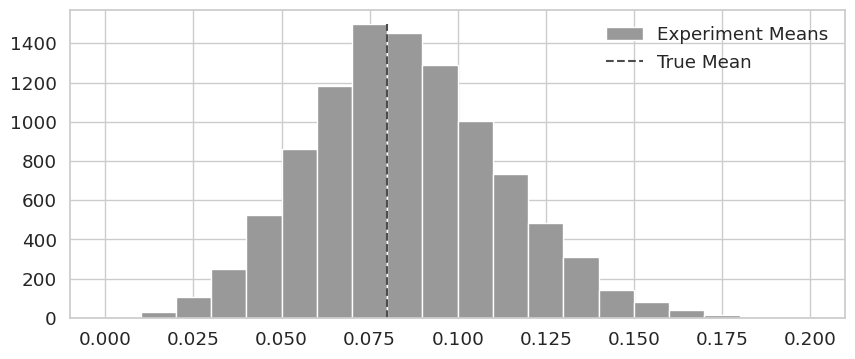

In [41]:
# Using 1.96 std dev to capture 95% of the density.
exp_se = short_email.sem()
exp_mu = short_email.mean()
ci = (exp_mu - 1.96 * exp_se, exp_mu + 1.96 * exp_se)
print("95% CI for short email:", ci)

In [ ]:
from scipy import stats

conf = 0.95
z = np.abs(stats.norm.ppf((1 - conf) / 2))
print("z=", z)
ci = (exp_mu - z * exp_se, exp_mu + z * exp_se)
print("ci=", ci)

In [ ]:
def ci(y: pd.Series) -> tuple:
    return (y.mean() - 2 * y.sem(), y.mean() + 2 * y.sem())


print("95% CI for short email:", ci(short_email))
print("95% CI for long email:", ci(long_email))
print("95% CI for no email:", ci(no_email))

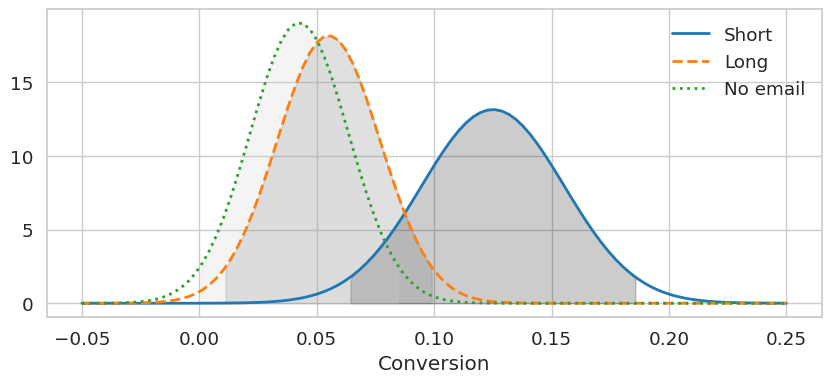

In [50]:
plt.figure(figsize=(10, 4))
linestyle = ["-", "--", ":", "-."]

x = np.linspace(-0.05, 0.25, 100)
short_dist = stats.norm.pdf(x, short_email.mean(), short_email.sem())
plt.plot(x, short_dist, lw=2, label="Short", linestyle=linestyle[0])
plt.fill_between(
    x.clip(ci(short_email)[0], ci(short_email)[1]),
    0,
    short_dist,
    alpha=0.2,
    color="0.0",
)

long_dist = stats.norm.pdf(x, long_email.mean(), long_email.sem())
plt.plot(x, long_dist, lw=2, label="Long", linestyle=linestyle[1])
plt.fill_between(
    x.clip(ci(long_email)[0], ci(long_email)[1]),
    0,
    long_dist,
    alpha=0.2,
    color="0.4",
)

no_email_dist = stats.norm.pdf(x, no_email.mean(), no_email.sem())
plt.plot(x, no_email_dist, lw=2, label="No email", linestyle=linestyle[2])
plt.fill_between(
    x.clip(ci(no_email)[0], ci(no_email)[1]),
    0,
    no_email_dist,
    alpha=0.2,
    color="0.8",
)

plt.xlabel("Conversion")
plt.legend()

## Cell 2.6: Hypothesis testing

- Assume that $H_0$ is that $\text{conv}(\text{no\_email}) =
  \text{conv}(\text{short\_email})$

In [53]:
diff_mu = short_email.mean() - no_email.mean()
diff_se = np.sqrt(no_email.sem() ** 2 + short_email.sem() ** 2)

ci = (diff_mu - 1.96 * diff_se, diff_mu + 1.96 * diff_se)
print(f"95% CI for the difference (short email - no email):\n{ci}")

95% CI for the differece (short email - no email):
(0.01023980847439844, 0.15465380854687816)


- $0$ is not included in the CI interval, so $H_0$ can be rejected at
  95% confidence
- Test if the "lift" between sending a short email and no email is
  more than 1%

In [ ]:
# Shifting the CI.
diff_mu_shifted = short_email.mean() - no_email.mean() - 0.01
diff_se = np.sqrt(no_email.sem() ** 2 + short_email.sem() ** 2)

ci = (diff_mu_shifted - 1.96 * diff_se, diff_mu_shifted + 1.96 * diff_se)
print(f"95% CI for 1% difference (short email - no email):\n{ci}")

## Cell 2.7: Test statistic

- A higher value typically means rejecting $H_0$
- E.g., $t\text{-stat} = \frac{\hat{\mu} - \mu_0}{\text{SE}}$

In [54]:
t_stat = (diff_mu - 0) / diff_se
print("t_stat=", t_stat)

95% CI 1% difference between (short email - no email):
(0.00023980847439844521, 0.14465380854687815)


## Cell 2.8: P-value

- Measure how likely it is to see an extreme value under $H_0$, i.e.,
  $P(\text{data} | H_0)$

In [59]:
print("p-value:", (1 - stats.norm.cdf(t_stat)) * 2)

p-value: 0.025224235562152142


## Cell 2.9: Power

- When designing an experiment, decide the sample size needed to
  reject $H_0$
- Power = probability of correctly rejecting $H_0$ when it is false
- Higher power requires larger samples; smaller effect sizes require
  even larger samples